# 11 — Does the per-drug z-scoring actually help? (`auc` vs `auc_z`)

The `auc_z` target (13.07.2026, [Step 03](../docs/steps/03-model-and-training-design.md)) standardizes
the AUC **within each drug**. The justification was argued from first principles — *"with 545 heads whose
`auc` spread ranges 0.034–0.302, the wide-spread drugs would supply ~80× more squared error than the
narrow ones and monopolize the shared trunk"* — but never **measured**. This notebook measures it, by
training the identical model on `--score auc` and `--score auc_z`.

**Why the comparison is fair.** `auc_z` is a *per-drug affine map* of `auc`
(`auc_z = (auc − center[d]) / scale[d]`), and per-drug Spearman is invariant to such a map — so the
**true ranking of cell lines is identical under both targets**, and the metric is directly comparable
across the two runs. The only channel through which the target scale can change a per-drug ranking is
the **multi-task coupling**: how the K heads share one trunk through one masked loss.

That yields a sharp, falsifiable prediction:

- **K=5** (the learnable subset, spreads 0.155–0.194 — nearly identical): almost nothing to equalize,
  so `auc` ≈ `auc_z`.
- **K=545** (spreads 0.034–0.302, a 9× span): the coupling bites, so `auc_z` should win.

If `auc` matched `auc_z` at K=545 too, the default would be unjustified and should be changed.

In [1]:
import os
import sys
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

from scripts.model.OncoMLP import OncoMLP
from scripts.model.dataset import MultiDrugDataset
from scripts.preprocessing.layout import PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

OUT = NB_DIR / 'outputs'
REPS = ['X_pca', 'X_scGPT']

# The 5 learnable drugs (notebook 08). Evaluation is always on THESE drugs, whatever K is trained.
lrn = pd.read_csv(OUT / 'ctrp_drug_learnability_auc.csv')
FIVE = lrn[lrn['learnable_strict']].sort_values('learnability', ascending=False).head(5)['drug'].tolist()
print('evaluation drugs:', FIVE)
print('their auc spread :', lrn.set_index('drug').loc[FIVE, 'auc_std'].round(3).to_dict())

evaluation drugs: ['1s,3r-rsl-3', 'kx2-391', 'cay10618', 'ml162', 'dasatinib']
their auc spread : {'1s,3r-rsl-3': 0.194, 'kx2-391': 0.179, 'cay10618': 0.177, 'ml162': 0.156, 'dasatinib': 0.155}


## The two targets on disk

Each `--score` writes its own targets h5ad, so both already exist — no rebuild needed:

```bash
uv run scripts/preprocessing/run_preprocessing.py --variant hvg5000 --all-drugs \
    --score auc --start-at targets --skip-scgpt      # ..._with_targets_auc.h5ad
```

Note the per-drug spread of the raw `auc` across all 545 drugs — the 9× span is the whole reason the
z-scoring exists.

In [2]:
spread = lrn['auc_std']
print(f'per-drug auc spread over {len(lrn)} drugs: '
      f'min {spread.min():.3f} | median {spread.median():.3f} | max {spread.max():.3f} '
      f'-> {spread.max() / spread.min():.0f}x span')
print(f'the 5 learnable drugs only:    '
      f'min {lrn[lrn.learnable_strict].auc_std.min():.3f} | '
      f'max {lrn[lrn.learnable_strict].auc_std.max():.3f}  <- nearly uniform, nothing to equalize')

per-drug auc spread over 545 drugs: min 0.034 | median 0.109 | max 0.302 -> 9x span
the 5 learnable drugs only:    min 0.155 | max 0.194  <- nearly uniform, nothing to equalize


## Train: 2 targets × 2 head-counts × 2 representations

Out-of-fold per-drug Spearman (5-fold GroupKFold over the 153 train+val lines), identical protocol to
[`09`](09_learnable5_training.ipynb) / [`10`](10_ablations.ipynb). Always scored on the same 5 drugs.

In [3]:
def oof_spearman(score, drugs, rep, eval_drugs):
    """Train K=len(drugs) heads on `score`; return per-drug OOF Spearman for `eval_drugs`."""
    paths = PipelinePaths.build(None, 'hvg5000', score)
    adata = sc.read_h5ad(paths.targets_h5ad)
    eligible = adata.obs['split_ctrp'].isin(['train', 'val']).to_numpy()
    groups = adata.obs['Cell_line'].astype(str).to_numpy()
    idx = np.flatnonzero(eligible)
    Y = np.asarray(adata.obsm['Y_ctrp'], dtype=float)
    M = np.asarray(adata.obsm['M_ctrp'], dtype=bool)
    ALL = list(adata.uns['ctrp_drugs'])

    cfg = TrainConfig(epochs=50, seed=42, log_every=1000)
    pred = np.full((adata.n_obs, len(drugs)), np.nan)
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=5).split(idx, groups=groups[idx]), 1):
        trc = np.zeros(adata.n_obs, bool); trc[idx[tr]] = True
        vac = np.zeros(adata.n_obs, bool); vac[idx[va]] = True
        tr_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=trc, drugs=drugs)
        va_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=vac, drugs=drugs)
        model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                        dropout_rate=0.5, input_dropout=0.1, norm='layer',
                        output_dim=len(tr_ds.drug_names))
        best, _ = train_model(model, DataLoader(tr_ds, batch_size=128, shuffle=True),
                              DataLoader(va_ds, batch_size=256, shuffle=False),
                              config=cfg, tag=f'{score}_{rep}_K{len(drugs)}_f{fold}',
                              drug_names=tr_ds.drug_names)
        best = best.to('cpu').eval()
        with torch.no_grad():
            X = torch.tensor(np.asarray(adata.obsm[rep], dtype=np.float32)[vac])
            pred[vac] = best(X).numpy()

    out = {}
    for drug in eval_drugs:
        j, k = drugs.index(drug), ALL.index(drug)
        t, p = [], []
        for line in np.unique(groups[eligible]):
            ci = np.flatnonzero((groups == line) & eligible)
            obs = ci[M[ci, k] & np.isfinite(pred[ci, j])]
            if obs.size:
                t.append(Y[obs, k].mean()); p.append(pred[obs, j].mean())
        out[drug] = spearmanr(np.asarray(p), np.asarray(t)).statistic
    return out


rows = []
for score in ['auc_z', 'auc']:
    all_drugs = list(sc.read_h5ad(PipelinePaths.build(None, 'hvg5000', score).targets_h5ad,
                                  backed='r').uns['ctrp_drugs'])
    for drugs, kname in [(FIVE, 'K=5'), (all_drugs, 'K=545')]:
        for rep in REPS:
            res = oof_spearman(score, drugs, rep, FIVE)
            for drug, rho in res.items():
                rows.append({'score': score, 'heads': kname, 'rep': rep, 'drug': drug, 'spearman': rho})
            print(f'{score:6s} {kname:6s} {rep:8s} mean rho = {np.mean(list(res.values())):+.3f}', flush=True)

df = pd.DataFrame(rows)
df.to_csv(OUT / 'auc_vs_aucz.csv', index=False)
print()
print(df.groupby(['heads', 'rep', 'score'])['spearman'].mean().unstack('score').round(3).to_string())

Loaded 33000 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31805 cells | max drug coverage=32724 cells.
Loaded 8247 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=7854 cells | max drug coverage=8247 cells.
[auc_z_X_pca_K5_f1] Training on device: mps
[auc_z_X_pca_K5_f1] Multi-task mode detected (masked MSE).


[auc_z_X_pca_K5_f1] Epoch [01/50] | Train MSE: 0.4843 | Val MSE: 0.9398 | LR: 1.0e-03  <- best
  best : cay10618:0.663(n=7854), 1s,3r-rsl-3:0.703(n=8247), dasatinib:0.784(n=7918), ml162:0.786(n=8247), kx2-391:1.750(n=8183)
  worst: kx2-391:1.750(n=8183), ml162:0.786(n=8247), dasatinib:0.784(n=7918), 1s,3r-rsl-3:0.703(n=8247), cay10618:0.663(n=7854)


[auc_z_X_pca_K5_f1] Epoch [05/50] | Train MSE: 0.1853 | Val MSE: 0.9083 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.644(n=8247), cay10618:0.678(n=7854), dasatinib:0.716(n=7918), ml162:0.794(n=8247), kx2-391:1.696(n=8183)
  worst: kx2-391:1.696(n=8183), ml162:0.794(n=8247), dasatinib:0.716(n=7918), cay10618:0.678(n=7854), 1s,3r-rsl-3:0.644(n=8247)


[auc_z_X_pca_K5_f1] Epoch [12/50] | Train MSE: 0.1605 | Val MSE: 0.9022 | LR: 5.0e-04  <- best
  best : 1s,3r-rsl-3:0.606(n=8247), cay10618:0.692(n=7854), ml162:0.726(n=8247), dasatinib:0.756(n=7918), kx2-391:1.722(n=8183)
  worst: kx2-391:1.722(n=8183), dasatinib:0.756(n=7918), ml162:0.726(n=8247), cay10618:0.692(n=7854), 1s,3r-rsl-3:0.606(n=8247)


[auc_z_X_pca_K5_f1] Early stopping at epoch 22 (no val improvement for 10 epochs).
[auc_z_X_pca_K5_f1] Training complete. Best Val MSE: 0.9022 at epoch 12.
Loaded 32995 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=32269 cells | max drug coverage=32616 cells.
Loaded 8252 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=7464 cells | max drug coverage=8252 cells.
[auc_z_X_pca_K5_f2] Training on device: mps
[auc_z_X_pca_K5_f2] Multi-task mode detected (masked MSE).


...

[auc_X_scGPT_K545_f5] Epoch [05/50] | Train MSE: 0.0280 | Val MSE: 0.0148 | LR: 1.0e-03  <- best
  best : brd-k41597374:0.001(n=8252), brd-k48477130:0.001(n=4069), brd-k16147474:0.001(n=7010), ml334 diastereomer:0.001(n=6277), cyclophosphamide:0.001(n=3785)
  worst: ifosfamide:0.102(n=3785), brd-k71781559:0.085(n=7481), brd-k34485477:0.077(n=1975), gsk461364:0.074(n=7372), tacrolimus:0.073(n=7854)


[auc_X_scGPT_K545_f5] Epoch [11/50] | Train MSE: 0.0279 | Val MSE: 0.0147 | LR: 5.0e-04  <- best
  best : brd-k41597374:0.001(n=8252), brd-k48477130:0.001(n=4069), brd-k16147474:0.001(n=7010), cyclophosphamide:0.001(n=3785), stemregenin 1:0.001(n=7622)
  worst: ifosfamide:0.098(n=3785), brd-k34485477:0.087(n=1975), brd-k71781559:0.083(n=7481), gsk461364:0.076(n=7372), at13387:0.072(n=4467)


[auc_X_scGPT_K545_f5] Early stopping at epoch 21 (no val improvement for 10 epochs).
[auc_X_scGPT_K545_f5] Training complete. Best Val MSE: 0.0147 at epoch 11.


auc    K=545  X_scGPT  mean rho = -0.087



score            auc  auc_z
heads rep                  
K=5   X_pca    0.441  0.432
      X_scGPT  0.482  0.488
K=545 X_pca    0.016  0.378
      X_scGPT -0.087  0.430


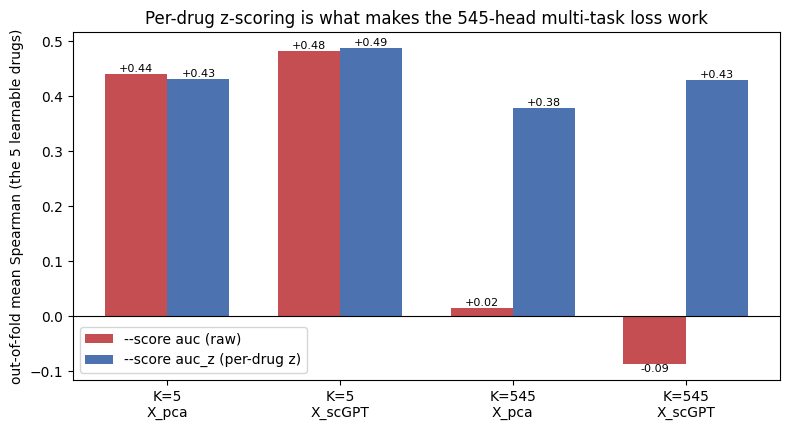

In [4]:
piv = df.groupby(['heads', 'rep', 'score'])['spearman'].mean().unstack('score')

fig, ax = plt.subplots(figsize=(8, 4.4))
labels = [f'{h}\n{r}' for h, r in piv.index]
x = np.arange(len(piv)); w = 0.36
ax.bar(x - w / 2, piv['auc'], w, label='--score auc (raw)', color='#C44E52')
ax.bar(x + w / 2, piv['auc_z'], w, label='--score auc_z (per-drug z)', color='#4C72B0')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('out-of-fold mean Spearman (the 5 learnable drugs)')
ax.set_title('Per-drug z-scoring is what makes the 545-head multi-task loss work')
ax.legend()
for i, (a, z) in enumerate(zip(piv['auc'], piv['auc_z'])):
    ax.annotate(f'{a:+.2f}', (i - w / 2, a), ha='center',
                va='bottom' if a >= 0 else 'top', fontsize=8)
    ax.annotate(f'{z:+.2f}', (i + w / 2, z), ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'auc_vs_aucz.png', dpi=200)
plt.show()

## Read-out — the prediction holds, and sharply

| | `auc` | `auc_z` |
|---|---|---|
| **K=5** · PCA | 0.441 | 0.432 |
| **K=5** · scGPT | 0.482 | 0.488 |
| **K=545** · PCA | **0.016** | **0.378** |
| **K=545** · scGPT | **−0.087** | **0.430** |

**At K=5 the two targets are indistinguishable** (±0.01, in both directions). Exactly as predicted: the
five filtered drugs have near-identical spread (0.155–0.194), so there is nothing for the standardization
to equalize, and per-drug Spearman cannot see a per-drug affine map. **If you only ever train on the
filtered subset, `--score auc` is equally good** — and it has the advantage of keeping predictions in
interpretable AUC units.

**At K=545, raw `auc` collapses to zero** (scGPT **−0.087**, PCA **+0.016**) while `auc_z` holds at
0.43 / 0.38. The multi-task coupling argument is confirmed: with 545 heads whose spreads span 9×
(0.034 → 0.302, i.e. ~80× in squared error), the wide-spread drugs monopolize the shared trunk's
gradient — **because of their units, not their learnability** — and the model learns nothing that
transfers. Per-drug standardization is what makes a 545-head masked MSE trainable at all.

### This retro-diagnoses the original null result

`07` §3 ("neither rep ranks cell lines", Spearman ≈ 0 over 545 drugs) was run at **K=545 on `mean_pv`** —
a target with exactly the same heterogeneous-variance pathology. That null was therefore **never clean
evidence about scGPT vs PCA**: a substantial part of it was an artifact of an **unstandardized multi-task
loss**, in which a minority of wide-spread heads drowned out everything else. The `auc` K=545 row above
*reproduces that failure on demand* — and z-scoring removes it.

**Decision: keep `auc_z` as the default target** (`layout.DEFAULT_CTRP_SCORE`). It is not cosmetic; at the
full drug catalog it is the difference between a model that ranks cell lines and one that does not. Use
`--score auc` only when training a small, spread-homogeneous subset *and* you want predictions in native
AUC units.